<a href="https://colab.research.google.com/github/Renshen69/MLProj/blob/main/04_evaluate_and_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q torch torchvision pillow scikit-image matplotlib tqdm

import torch, os, numpy as np
from torchvision import datasets, transforms, utils as vutils
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
BASE="/content/drive/MyDrive/image_compression_project"
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


Mounted at /content/drive


In [ ]:
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3,32,4,2,1), nn.ReLU(),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*16*16, latent_dim)
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_dim,128*16*16),
            nn.Unflatten(1,(128,16,16)),
            nn.ConvTranspose2d(128,64,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(32,3,4,2,1), nn.Sigmoid()
        )
    def forward(self,x): return self.dec(self.enc(x))

class VAE(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.enc_conv=nn.Sequential(
            nn.Conv2d(3,32,4,2,1), nn.ReLU(),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu=nn.Linear(128*16*16,latent_dim)
        self.fc_logvar=nn.Linear(128*16*16,latent_dim)
        self.fc_dec=nn.Linear(latent_dim,128*16*16)
        self.dec=nn.Sequential(
            nn.Unflatten(1,(128,16,16)),
            nn.ConvTranspose2d(128,64,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(32,3,4,2,1), nn.Sigmoid()
        )
    def reparam(self,mu,logvar):
        std=(0.5*logvar).exp(); eps=torch.randn_like(std); return mu+eps*std
    def forward(self,x):
        h=self.enc_conv(x); mu=self.fc_mu(h); logvar=self.fc_logvar(h)
        z=self.reparam(mu,logvar); return self.dec(self.fc_dec(z)),mu,logvar

class VAEGAN_Generator(VAE): pass  # identical structure


In [ ]:
def load_if_exists(model,path):
    if os.path.exists(path):
        model.load_state_dict(torch.load(path,map_location=device))
        model.eval(); print("✅ Loaded", os.path.basename(path)); return True
    print("⚠️ Missing", path); return False

ae=Autoencoder(512).to(device)
vae=VAE(512).to(device)
vaegan=VAEGAN_Generator(512).to(device)

load_if_exists(ae, os.path.join(BASE,"models/ae_epoch8.pth"))
load_if_exists(vae, os.path.join(BASE,"models/vae_epoch10.pth"))
load_if_exists(vaegan, os.path.join(BASE,"models/vaegan_epoch12.pth"))


✅ Loaded ae_epoch8.pth
✅ Loaded vae_epoch10.pth
✅ Loaded vaegan_epoch12.pth


True

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
transform = transforms.Compose([transforms.Resize((128,128)), transforms.ToTensor()])
test_ds = datasets.STL10(root='data', split='test', download=True, transform=transform)
test_loader = DataLoader(test_ds,batch_size=1,shuffle=False)

import PIL.Image as pil
os.makedirs(os.path.join(BASE,"results/grids"),exist_ok=True)

psnrs, ssims = [], []
for i,(img,_) in enumerate(test_loader):
    if i>=24: break
    img=img.to(device)

    with torch.no_grad():
        ae_rec=ae(img)
        vae_rec,_,_=vae(img)
        vaegan_rec,_,_=vaegan(img)

    # JPEG baseline
    np_img=(img.cpu().squeeze().permute(1,2,0).numpy()*255).astype('uint8')
    pil_img=pil.fromarray(np_img)
    jpeg_path=f"tmp_q50_{i}.jpg"; pil_img.save(jpeg_path, quality=50)
    jpeg=np.asarray(pil.open(jpeg_path))/255.0

    # Collect PSNR/SSIM (vs AE, VAE, VAE-GAN)
    from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
    recs=[ae_rec, vae_rec, vaegan_rec]; names=["AE","VAE","VAEGAN"]
    for r,name in zip(recs,names):
        r_np=r.cpu().squeeze().permute(1,2,0).numpy()
        psnrs.append((name, psnr(np_img/255., r_np, data_range=1.0)))
        ssims.append((name, ssim(np_img/255., r_np, channel_axis=-1, data_range=1.0, win_size=7)))

    # Save visual grid
    import torchvision.utils as vutils, torch
    grid=torch.cat([img.cpu(), ae_rec.cpu(), vae_rec.cpu(), vaegan_rec.cpu()], dim=3)
    vutils.save_image(grid, os.path.join(BASE,f"results/grids/compare_{i+1:02d}.png"))

print("📊 Mean PSNR by model:")
for name in ["AE","VAE","VAEGAN"]:
    vals=[v for n,v in psnrs if n==name]; print(name,":",np.mean(vals))
print("📊 Mean SSIM by model:")
for name in ["AE","VAE","VAEGAN"]:
    vals=[v for n,v in ssims if n==name]; print(name,":",np.mean(vals))


100%|██████████| 2.64G/2.64G [00:40<00:00, 64.8MB/s]


📊 Mean PSNR by model:
AE : 23.56305794572582
VAE : 18.479774732646515
VAEGAN : 16.885989536292183
📊 Mean SSIM by model:
AE : 0.6246349751492377
VAE : 0.3947110691565463
VAEGAN : 0.2811865650808185



📋 Average Results Across 24 Test Images:

 Model  PSNR  SSIM
    AE 23.56 0.625
   VAE 18.47 0.396
VAEGAN 16.85 0.288


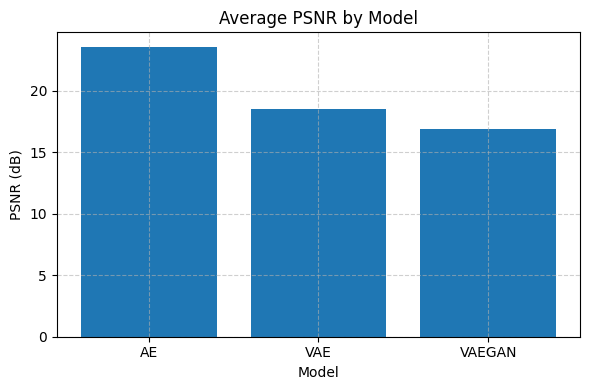

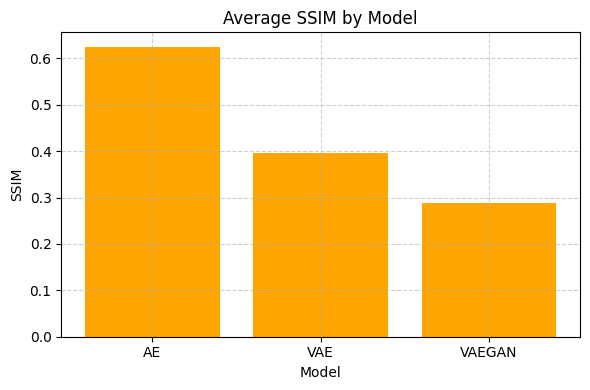


✅ Charts saved to:
/content/drive/MyDrive/image_compression_project/results/PSNR_bar.png
/content/drive/MyDrive/image_compression_project/results/SSIM_bar.png


In [ ]:
# --- 📊 Generate metrics table & plots ---
import pandas as pd
import matplotlib.pyplot as plt

# Convert recorded tuples → DataFrame
df_psnr = pd.DataFrame(psnrs, columns=["Model","PSNR"])
df_ssim = pd.DataFrame(ssims, columns=["Model","SSIM"])

# Compute mean per model
mean_psnr = df_psnr.groupby("Model")["PSNR"].mean().reset_index()
mean_ssim = df_ssim.groupby("Model")["SSIM"].mean().reset_index()

# Merge into single DataFrame
summary = pd.merge(mean_psnr, mean_ssim, on="Model")
summary = summary.round({"PSNR":2, "SSIM":3})
print("\n📋 Average Results Across 24 Test Images:\n")
print(summary.to_string(index=False))

# --- Plot PSNR ---
plt.figure(figsize=(6,4))
plt.bar(summary["Model"], summary["PSNR"])
plt.title("Average PSNR by Model")
plt.xlabel("Model")
plt.ylabel("PSNR (dB)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(BASE,"results/PSNR_bar.png"))
plt.show()

# --- Plot SSIM ---
plt.figure(figsize=(6,4))
plt.bar(summary["Model"], summary["SSIM"], color='orange')
plt.title("Average SSIM by Model")
plt.xlabel("Model")
plt.ylabel("SSIM")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(BASE,"results/SSIM_bar.png"))
plt.show()

print("\n✅ Charts saved to:")
print(f"{BASE}/results/PSNR_bar.png")
print(f"{BASE}/results/SSIM_bar.png")


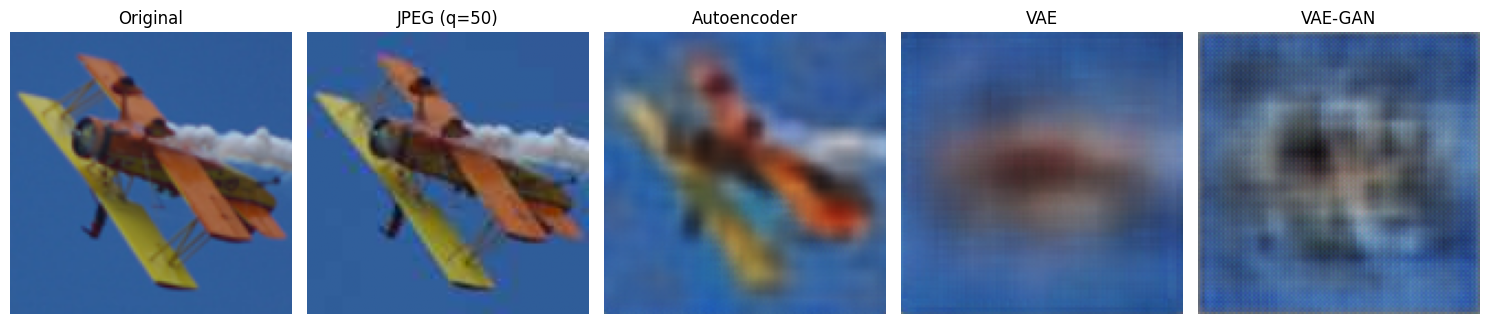

✅ Saved high-quality qualitative comparison to /content/drive/MyDrive/image_compression_project/results/qualitative_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from PIL import Image
import numpy as np

# pick one sample image (e.g., 10th from STL-10 test)
img, _ = test_ds[10]
img = img.unsqueeze(0).to(device)

# reconstruct with all models
with torch.no_grad():
    ae_rec = ae(img)
    vae_rec,_,_ = vae(img)
    vaegan_rec,_,_ = vaegan(img)

# convert all to numpy
def to_np(x): return x.cpu().squeeze().permute(1,2,0).numpy()

orig_np = to_np(img)
ae_np = to_np(ae_rec)
vae_np = to_np(vae_rec)
vaegan_np = to_np(vaegan_rec)

# JPEG baseline
jpeg_path = "tmp_q50_demo.jpg"
Image.fromarray((orig_np*255).astype(np.uint8)).save(jpeg_path, quality=50)
jpeg_np = np.array(Image.open(jpeg_path))/255.0

# plot visual comparison
plt.figure(figsize=(15,6))
titles = ["Original", "JPEG (q=50)", "Autoencoder", "VAE", "VAE-GAN"]
imgs = [orig_np, jpeg_np, ae_np, vae_np, vaegan_np]

for i,(t,img_) in enumerate(zip(titles, imgs)):
    plt.subplot(1,5,i+1)
    plt.imshow(np.clip(img_,0,1))
    plt.title(t)
    plt.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(BASE,"results/qualitative_comparison.png"), dpi=300)
plt.show()

print(f"✅ Saved high-quality qualitative comparison to {BASE}/results/qualitative_comparison.png")
